
<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Arial, sans-serif;
  line-height: 1.7;
  color: #1f2937;
  background: #0b1020;
  padding: 28px 30px;
  border-radius: 16px;
  box-shadow: 0 10px 30px rgba(0,0,0,0.25);
  max-width: 980px;
">

  <!-- Title -->
  <h1 style="
    color: #e6edf3;
    font-size: 30px;
    margin: 0 0 10px 0;
    letter-spacing: 0.3px;
  ">
    Variational Autoencoder (VAE) in Keras
  </h1>
  

  <!-- 1. Purpose -->
  <h2 style="
    color: #7dd3fc;
    font-size: 22px;
    margin-top: 22px;
    border-left: 4px solid #38bdf8;
    padding-left: 10px;
  ">
    1. Purpose
  </h2>
  <p style="color:#d1d9e6; font-size:16px;">
    This notebook demonstrates how to implement and train a
    <strong style="color:#fbbf24;">Variational Autoencoder (VAE)</strong> using
    <strong style="color:#a78bfa;">Keras/TensorFlow</strong> on satellite imagery.
    It loads EuroSAT images from a local directory, preprocesses them, builds a VAE
    (encoder + sampling + decoder), trains with a custom loss, and visualizes both
    reconstructions and newly generated samples.
    The notebook serves as an end-to-end example of generative modeling on real remote-sensing data.
  </p>

  <!-- 1.5 Theory -->
  <h2 style="
    color: #7dd3fc;
    font-size: 22px;
    margin-top: 26px;
    border-left: 4px solid #38bdf8;
    padding-left: 10px;
  ">
    1.5 Autoencoder Theory Background
  </h2>
  <div style="background:#0f172a; padding:18px 20px; border-radius:12px; border:1px solid #1e293b; color:#d1d9e6; font-size:16px; line-height:1.7;">

  <!-- Inserted Image -->
  <div style="text-align:center; margin-bottom:18px;">
    <img src="/Users/fuyuhan/Desktop/VAE.png"
         style="width:80%; border-radius:10px; border:1px solid #1e293b;">
    <p style="color:#9fb3c8; font-size:14px; margin-top:6px;">
      Figure: The autoencoder compresses the input into a latent code and reconstructs it.
    </p>
  </div>

  <p style="margin-top:0;">
    <span style="color:#fbbf24; font-weight:600;">Autoencoding</span> is a
    data compression algorithm where the compression and decompression functions are:
  </p>

  <ul style="margin-left:16px;">
    <li><strong style="color:#34d399;">data-specific</strong></li>
    <li><strong style="color:#34d399;">lossy</strong></li>
    <li><strong style="color:#34d399;">learned automatically</strong> from examples rather than engineered by humans</li>
  </ul>

  <p>
    In modern machine learning, an <strong style="color:#a78bfa;">autoencoder</strong>
    almost always refers to a neural-network-based system: the encoder maps an input to a low-dimensional latent representation,
    and the decoder reconstructs the data from that compressed code.
  </p>

  <h3 style="color:#c4b5fd; margin-top:18px; font-size:19px;">Data-Specific Compression</h3>
  <p>
    Autoencoders only compress data similar to what they were trained on.
    A model trained on <span style="color:#93c5fd;">faces</span> learns face-specific structure and will
    perform poorly on trees or buildings. This differs from general-purpose codecs like 
    <strong style="color:#f87171;">MP3/JPEG</strong>, which rely on broad assumptions about sound or images.
  </p>

  <h3 style="color:#c4b5fd; margin-top:18px; font-size:19px;">Lossy Reconstruction</h3>
  <p>
    Autoencoders are inherently <strong style="color:#f87171;">lossy</strong>:
    reconstructions degrade compared to the original inputs, similar to MP3 or JPEG compression.
    This differs from lossless techniques such as arithmetic coding.
  </p>

  <h3 style="color:#c4b5fd; margin-top:18px; font-size:19px;">Learning the Compression Automatically</h3>
  <p>
    The encoder and decoder are <strong style="color:#34d399;">learned automatically</strong> from data.
    To adapt an autoencoder to a new domain, you only need new training examples—no additional manual
    algorithm design is required.
  </p>

</div>


  <!-- 2. Workflow -->
  <h2 style="
    color: #7dd3fc;
    font-size: 22px;
    margin-top: 24px;
    border-left: 4px solid #38bdf8;
    padding-left: 10px;
  ">
    2. High-Level Workflow
  </h2>

  <ol style="color:#d1d9e6; font-size:16px; padding-left: 20px;">
    <li>
      <strong style="color:#f472b6;">Import dependencies</strong>
      (TensorFlow/Keras, OpenCV, NumPy, Matplotlib).
    </li>
    <li>
      <strong style="color:#f472b6;">Load EuroSAT images from disk</strong>
      using <code style="color:#93c5fd;">tf.keras.utils.image_dataset_from_directory</code>,
      with <code style="color:#93c5fd;">img_size = 128</code> and
      <code style="color:#93c5fd;">batch_size = 32</code>.
    </li>
    <li>
      <strong style="color:#f472b6;">Visualize samples</strong>
      to verify correct class selection (e.g., AnnualCrop).
    </li>
    <li>
      <strong style="color:#f472b6;">Convert TF datasets to NumPy arrays</strong>
      (<code style="color:#93c5fd;">x_train</code>, <code style="color:#93c5fd;">x_test</code>)
      for model input.
    </li>
    <li>
      <strong style="color:#f472b6;">Define the VAE</strong>:
      <ul style="margin-top:6px;">
        <li><span style="color:#fbbf24; font-weight:600;">Encoder</span> outputs
          <code style="color:#93c5fd;">z_mean</code> and
          <code style="color:#93c5fd;">z_log_var</code>.
        </li>
        <li><span style="color:#fbbf24; font-weight:600;">Sampling layer</span>
          applies the reparameterization trick.
        </li>
        <li><span style="color:#fbbf24; font-weight:600;">Decoder</span>
          reconstructs images via transposed convolutions.
        </li>
      </ul>
    </li>
    <li>
      <strong style="color:#f472b6;">Train with custom VAE loss</strong>
      (reconstruction + KL divergence).
    </li>
    <li>
      <strong style="color:#f472b6;">Evaluate & visualize</strong>
      reconstructions and latent-space generations.
    </li>
  </ol>

  <!-- 3. Key Components -->
  <h2 style="
    color: #7dd3fc;
    font-size: 22px;
    margin-top: 24px;
    border-left: 4px solid #38bdf8;
    padding-left: 10px;
  ">
    3. Key Components Explained
  </h2>

  <h3 style="color:#c4b5fd; font-size:19px; margin-top: 12px;">
    3.1 Data Loading
  </h3>
  <p style="color:#d1d9e6; font-size:16px;">
    The notebook expects a local folder structure like:
  </p>

  <pre style="
    background:#0f172a;
    color:#e2e8f0;
    padding:12px 14px;
    border-radius:10px;
    font-size:14px;
    overflow-x:auto;
    border:1px solid #1f2a44;
  ">2750/
  AnnualCrop/
    *.jpg</pre>

  <p style="color:#d1d9e6; font-size:16px;">
    It builds a <strong style="color:#fbbf24;">training set</strong> and a
    <strong style="color:#fbbf24;">validation set</strong> to ensure the model is
    evaluated on unseen images.
  </p>

  <h3 style="color:#c4b5fd; font-size:19px; margin-top: 12px;">
    3.2 NumPy Conversion
  </h3>
  <p style="color:#d1d9e6; font-size:16px;">
    Dataset batches are concatenated into arrays
    <code style="color:#93c5fd;">x_train</code> and
    <code style="color:#93c5fd;">x_test</code>. This simplifies a custom training loop
    and is suitable for moderate-sized datasets.
  </p>

  <h3 style="color:#c4b5fd; font-size:19px; margin-top: 12px;">
    3.3 VAE Architecture
  </h3>
  <p style="color:#d1d9e6; font-size:16px;">
    The <strong style="color:#fbbf24;">encoder</strong> learns a distribution of latent codes,
    producing <code style="color:#93c5fd;">z_mean</code> and
    <code style="color:#93c5fd;">z_log_var</code>.
    The <strong style="color:#fbbf24;">sampling layer</strong> draws latent vectors stochastically,
    and the <strong style="color:#fbbf24;">decoder</strong> reconstructs the image.
    This setup yields a smooth latent space enabling meaningful sampling.
  </p>

  <h3 style="color:#c4b5fd; font-size:19px; margin-top: 12px;">
    3.4 Custom Loss
  </h3>
  <p style="color:#d1d9e6; font-size:16px;">
    Training minimizes:
    <strong style="color:#fbbf24;">total loss = reconstruction loss + KL divergence</strong>.
    Reconstruction (often MSE) preserves pixel-level information, while KL divergence regularizes
    the latent space toward a standard normal distribution.
  </p>

  <!-- 4. How to Run -->
  <h2 style="
    color: #7dd3fc;
    font-size: 22px;
    margin-top: 24px;
    border-left: 4px solid #38bdf8;
    padding-left: 10px;
  ">
    4. How to Run
  </h2>
  <ol style="color:#d1d9e6; font-size:16px; padding-left: 20px;">
    <li>Set the correct dataset directory (e.g., <code style="color:#93c5fd;">2750/AnnualCrop</code>).</li>
    <li>Run the notebook top-to-bottom to load data, build the VAE, and train.</li>
    <li>Inspect reconstruction and generation plots at the end.</li>
    <li>GPU acceleration is recommended for faster convergence.</li>
  </ol>

  <!-- 5. Use Cases -->
  <h2 style="
    color: #7dd3fc;
    font-size: 22px;
    margin-top: 24px;
    border-left: 4px solid #38bdf8;
    padding-left: 10px;
  ">
    5. Use Cases
  </h2>
  <ul style="color:#d1d9e6; font-size:16px; padding-left: 20px;">
    <li>Learning VAE fundamentals and the reparameterization trick.</li>
    <li>Remote-sensing feature learning using latent representations.</li>
    <li>Baseline generative modeling for EuroSAT or similar datasets.</li>
    <li>Extending to conditional or multi-class VAEs for controlled generation.</li>
  </ul>

  

  <!-- Footer -->
  <p style="
    color:#9fb3c8;
    font-size:15px;
    margin-top:18px;
    padding-top:12px;
    border-top:1px dashed #24324d;
  ">
    <strong style="color:#e6edf3;">Summary:</strong>
    This notebook provides a compact, practical VAE pipeline that goes from raw EuroSAT images
    to a trained generative model capable of reconstructing and synthesizing satellite imagery.
  </p>

</div>


In [1]:
import os
import cv2
import keras
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras import backend as K
from keras import metrics
from keras.losses import MeanSquaredError
import numpy as np
from tensorflow.keras.layers import Input, Dense, Lambda, Conv2D, Flatten, Reshape, Conv2DTranspose,BatchNormalization,LeakyReLU,Dropout
import tensorflow as tf

In [2]:
import tensorflow as tf
base_dir = '2750/AnnualCrop'
batch_size = 32
img_size = 128

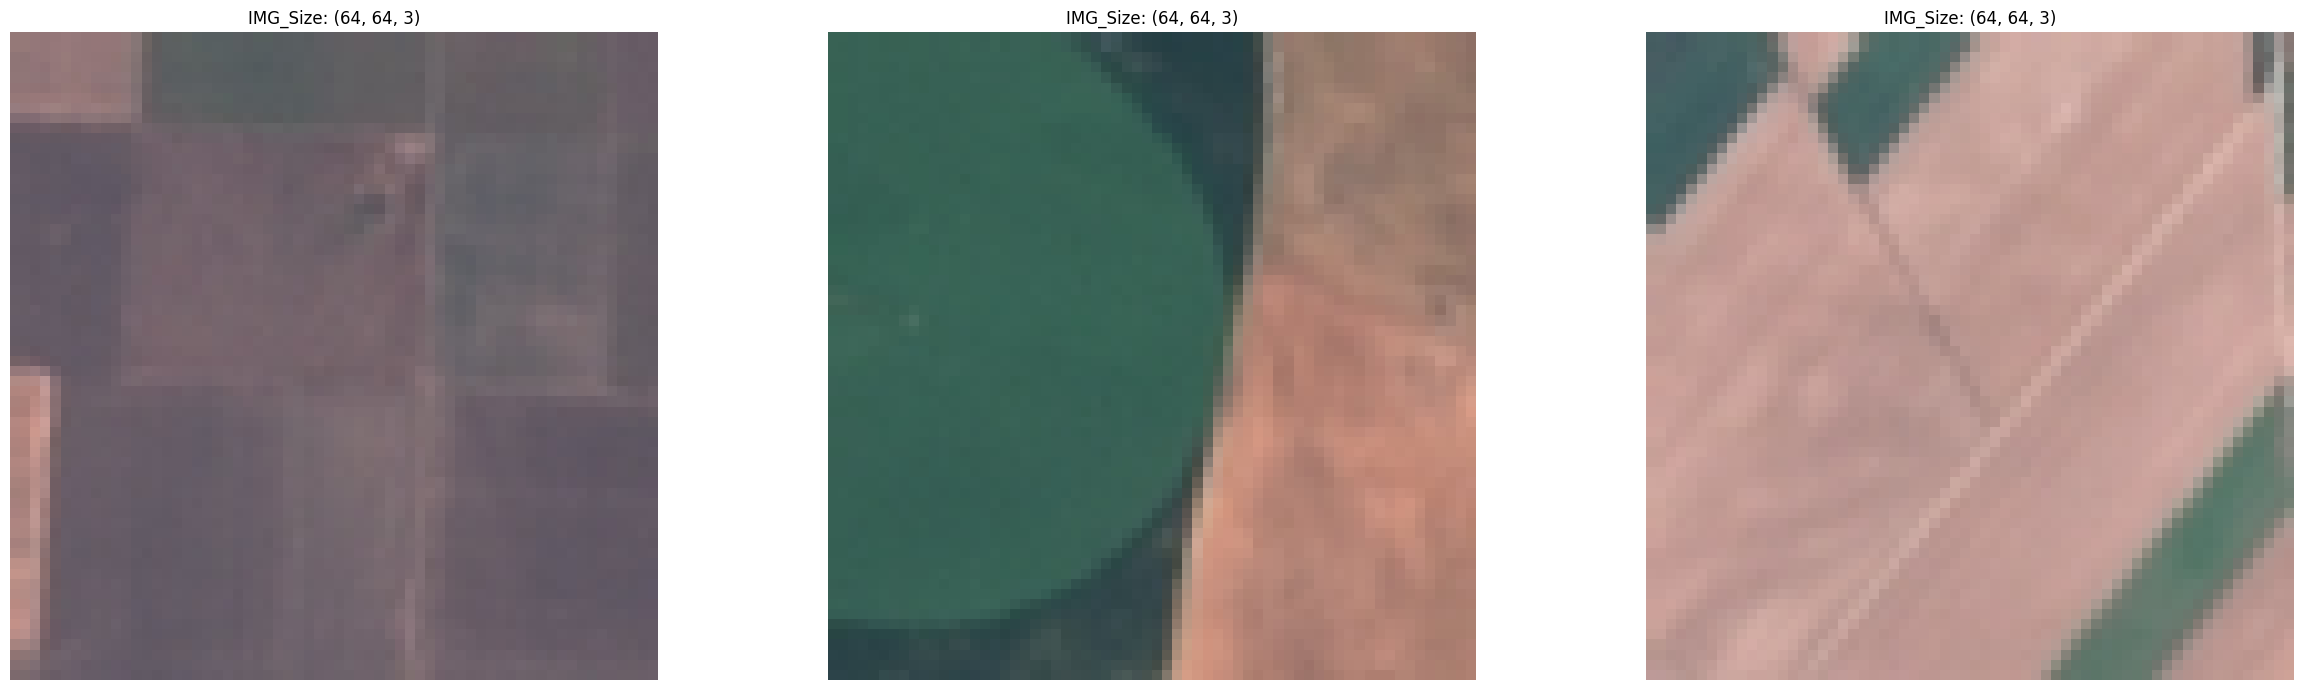

In [3]:
train_folder= '2750'

files = ['AnnualCrop']

def Display_IMAGES(folder):
    for file in files:
        path = os.path.join(folder, file)
        fig, axes = plt.subplots(1, 3, figsize=(25, 7)) 
        for i, img in enumerate(os.listdir(path)[:3]): 
            img_array = cv2.imread(os.path.join(path, img))
            
            
            img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
            
            img_shape = img_rgb.shape
            axes[i].imshow(img_rgb)
            axes[i].set_title(f"IMG_Size: {img_shape}")
            axes[i].axis('off')
            
        plt.tight_layout()
    
    plt.show()

Display_IMAGES(train_folder)


In [5]:
training_set = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  label_mode="int",
  validation_split=0.02,
  subset="training",
  seed=100,
  image_size=(img_size, img_size),
  batch_size=batch_size,
  class_names=["AnnualCrop"]
  )


Found 3000 files belonging to 1 classes.
Using 2940 files for training.


In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
  train_folder,
  validation_split=0.2,
  subset="validation",
  seed=100,
  image_size=(img_size, img_size),
  batch_size=batch_size)

Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


In [7]:
import numpy as np
x_train = np.array([])
for x, y in training_set:
  x_train = np.concatenate([x])

In [8]:
x_test = np.array([])
for x, y in validation_set:
  x_test = np.concatenate([x])

['AnnualCrop']


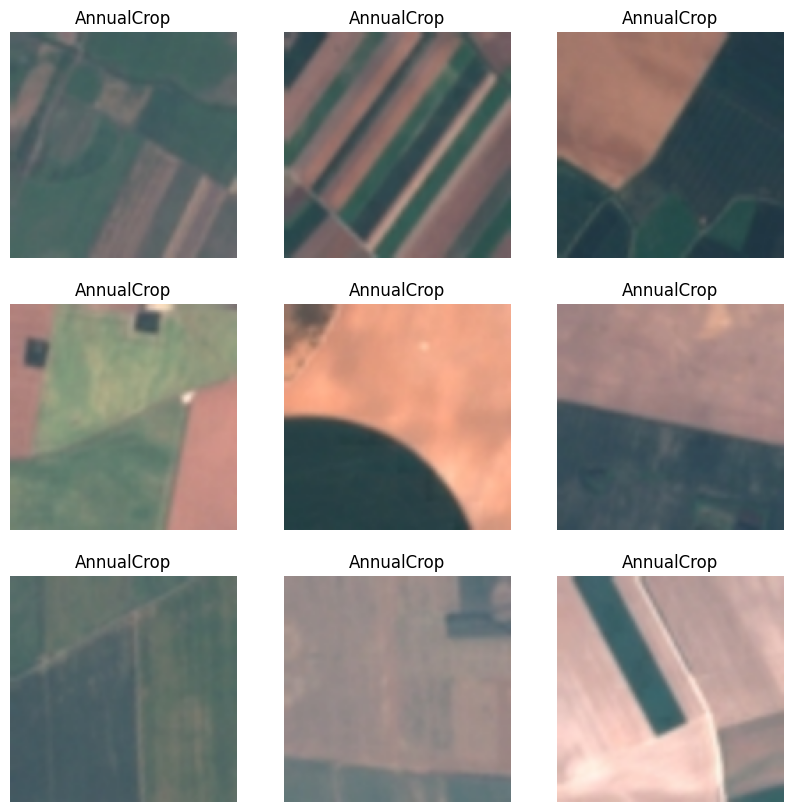

In [9]:
import matplotlib.pyplot as plt
class_names = training_set.class_names
print(class_names)
plt.figure(figsize=(10, 10))
for images, labels in training_set.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [10]:
# Normalize pixel values between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [21]:
import tensorflow as tf
import keras
from keras import layers
import numpy as np


# Configurations

latent_dim = 2
BETA = 1000     # scaling factor for reconstruction
img_size = 128   # or whatever size you're using
input_shape = (img_size, img_size, 3)


# Sampling Layer

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


# Encoder

encoder_inputs = keras.Input(shape=input_shape)

x = layers.Conv2D(16, 3, activation='relu', padding='same')(encoder_inputs)
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)

shape_before_flatten = x.shape[1:]

x = layers.Flatten()(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


# Decoder

decoder_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(np.prod(shape_before_flatten), activation='relu')(decoder_inputs)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.Conv2DTranspose(128, 3, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Conv2DTranspose(32, 3, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(16, 3, activation='relu', padding='same')(x)

decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")


# VAE Class

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return z_mean, z_log_var, reconstruction

    def train_step(self, data):
        x = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, reconstruction = self(x, training=True)

            # reconstruction loss
            mse = tf.keras.losses.MeanSquaredError()
            reconstruction_loss = BETA * mse(x, reconstruction)

            # KL loss
            kl_loss = tf.reduce_mean(
                tf.reduce_sum(
                    -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        x = data

        z_mean, z_log_var, reconstruction = self(x, training=False)
        mse = tf.keras.losses.MeanSquaredError()
        reconstruction_loss = BETA * mse(x, reconstruction)

        kl_loss = tf.reduce_mean(
            tf.reduce_sum(
                -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)),
                axis=1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }


# Build and Train VAE

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())

# training
vae.fit(
    x_train,
    #epochs=500,
    epochs=300,
    batch_size=batch_size,
    validation_data=(x_test)
)


Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - kl_loss: 0.0011 - loss: 26.1483 - reconstruction_loss: 26.1472 - val_kl_loss: 47.2313 - val_loss: 84.2133 - val_reconstruction_loss: 36.9820
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - kl_loss: 147.8489 - loss: 173.7741 - reconstruction_loss: 25.9252 - val_kl_loss: 0.2023 - val_loss: 37.4178 - val_reconstruction_loss: 37.2156
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - kl_loss: 0.2289 - loss: 26.1485 - reconstruction_loss: 25.9196 - val_kl_loss: 0.1701 - val_loss: 37.8083 - val_reconstruction_loss: 37.6383
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - kl_loss: 0.3166 - loss: 26.0134 - reconstruction_loss: 25.6968 - val_kl_loss: 0.0683 - val_loss: 38.5664 - val_reconstruction_loss: 38.4981
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - kl_loss: 0.1438 - loss: 25.4479 - reconstruction_loss: 25.3041 - val_kl_loss: 0.0024 - val_loss: 40.3205 - val_reconstruction_loss: 40.3181
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


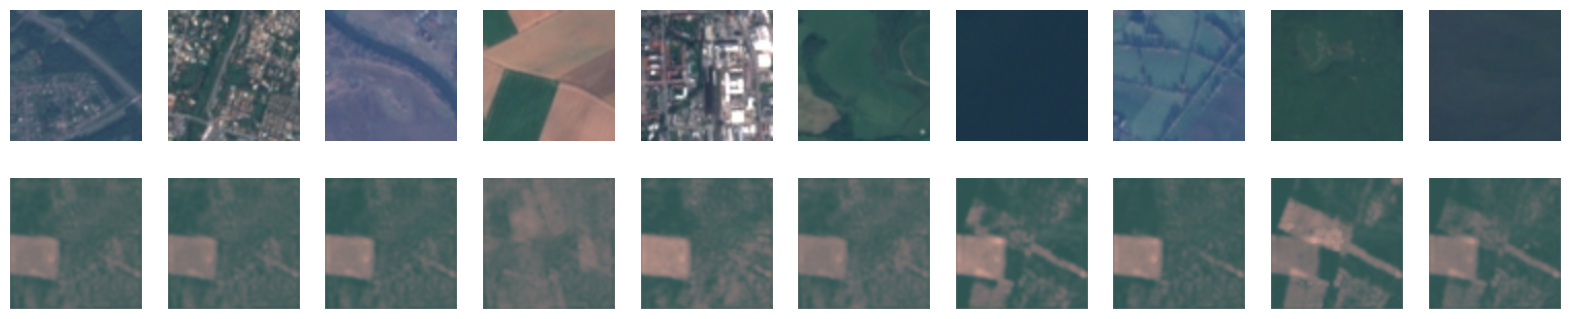

In [22]:
import matplotlib.pyplot as plt

# Only take reconstructions 
_, _, decoded_imgs = vae.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    ax.axis("off")

    # reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    ax.axis("off")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step


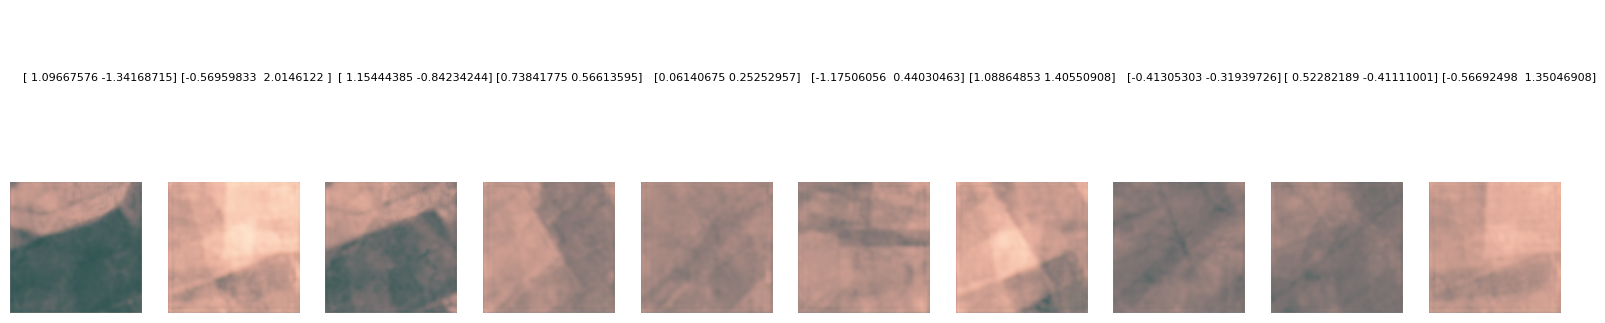

In [23]:
num_samples = 10


random_latent_vectors = np.random.normal(size=(num_samples, latent_dim))


decoded_imgs = decoder.predict(random_latent_vectors)


plt.figure(figsize=(20, 4))

for i in range(num_samples):
    # Show latent vector as text
    ax = plt.subplot(2, num_samples, i + 1)
    plt.text(0.1, 0.5, str(random_latent_vectors[i]), fontsize=8)
    ax.axis("off")

    # Show generated image
    ax = plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.imshow(decoded_imgs[i])
    ax.axis("off")

plt.show()

In [24]:
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │        448 │ input_layer_9[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │      4,640 │ conv2d_20[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │     36,992 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │    295,168 │ conv2d_22[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1048576)   │          0 │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 2)         │  2,097,154 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 2)         │  2,097,154 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_4          │ (None, 2)         │          0 │ dense_12[0][0],   │
│ (Sampling)          │                   │            │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,531,556 (17.29 MB)

 Trainable params: 4,531,556 (17.29 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1048576)        │     3,145,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 64, 64, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 128, 128, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 128, 128, 16)   │         4,624 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 128, 128, 3)    │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,538,083 (13.50 MB)

 Trainable params: 3,538,083 (13.50 MB)

 Non-trainable params: 0 (0.00 B)